In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread

In [3]:
#import tensorflow as tf
#print("TensorFlow version:", tf.__version__)
#print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))


In [86]:
my_data_dir = 'C:\\Users\\wayne\\OneDrive\\桌面\\Final Project Dataset\\cell_images\\cell_images'

In [87]:
os.listdir(my_data_dir) 

['test', 'train']

In [88]:
test_path = my_data_dir+'\\test\\'
train_path = my_data_dir+'\\train\\'

In [89]:
os.listdir(test_path)

['parasitized', 'uninfected']

In [90]:
os.listdir(train_path)

['parasitized', 'uninfected']

In [91]:
os.listdir(train_path+'\\parasitized')[2]

'C100P61ThinF_IMG_20150918_144104_cell_164.png'

In [92]:
para_cell = train_path+'\\parasitized'+'\\C100P61ThinF_IMG_20150918_144104_cell_164.png'

In [93]:
para_img= imread(para_cell)

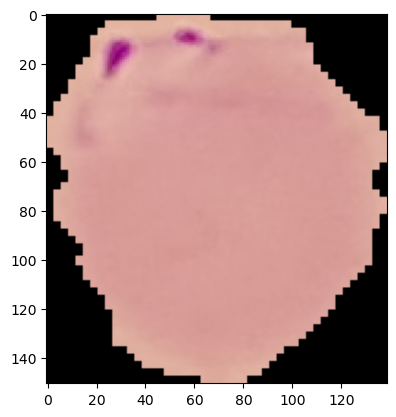

In [94]:
plt.imshow(para_img)

In [95]:
para_img.shape

(151, 139, 3)

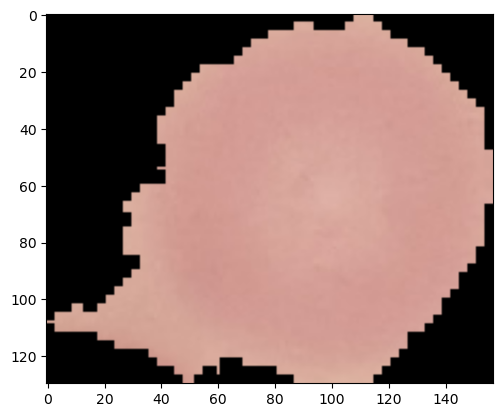

In [96]:
unifected_cell_path = train_path+'\\uninfected\\'+os.listdir(train_path+'\\uninfected')[5]
unifected_cell = imread(unifected_cell_path)
plt.imshow(unifected_cell)

In [97]:
len(os.listdir(train_path+'\\parasitized'))

12480

In [98]:
len(os.listdir(train_path+'\\uninfected'))

12480

**Average Dimension of the images**

In [100]:
unifected_cell.shape

(130, 157, 3)

In [101]:
para_img.shape

(151, 139, 3)

In [102]:
dim1 = []
dim2 = []
for image_filename in os.listdir(test_path+'\\uninfected'):
    
    img = imread(test_path+'\\uninfected'+'\\'+image_filename)
    d1,d2,colors = img.shape
    dim1.append(d1)
    dim2.append(d2)

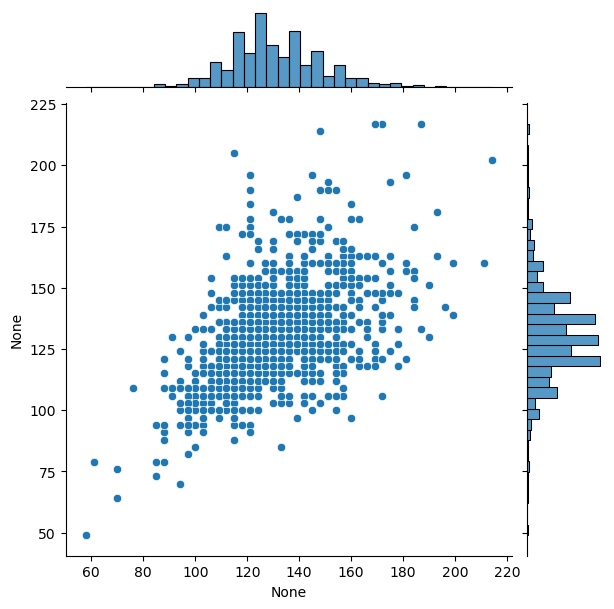

In [103]:
sns.jointplot(x=dim1,y=dim2)

In [104]:
np.mean(dim1)

130.92538461538462

In [105]:
np.mean(dim2)

130.75

In [106]:
image_shape = (130,130,3)

In [107]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [108]:
image_gen = ImageDataGenerator(rotation_range=20, 
                               width_shift_range=0.10, 
                               height_shift_range=0.10, 
                               rescale=1/255, 
                               shear_range=0.1, 
                               zoom_range=0.1, 
                               horizontal_flip=True, 
                               fill_mode='nearest' 
                              )

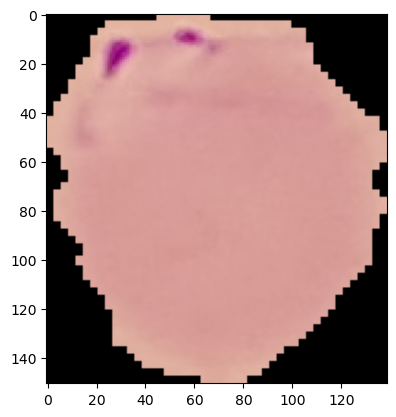

In [109]:
plt.imshow(para_img)

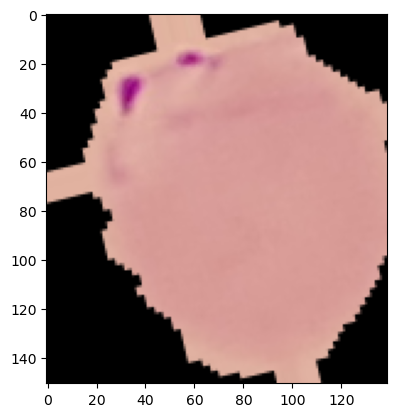

In [110]:
plt.imshow(image_gen.random_transform(para_img))

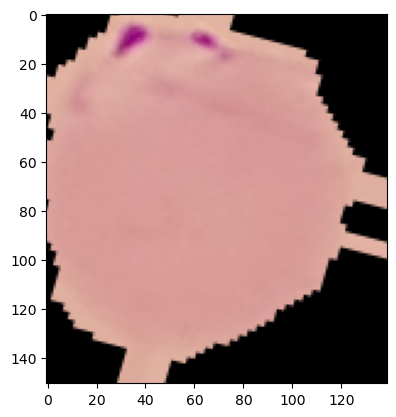

In [111]:
plt.imshow(image_gen.random_transform(para_img))

In [112]:
image_gen.flow_from_directory(train_path)

Found 24958 images belonging to 2 classes.


In [113]:
image_gen.flow_from_directory(test_path)

Found 2600 images belonging to 2 classes.


# Creating the Model

In [115]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization, Dense, Dropout, Activation, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2

In [116]:
model = Sequential()

model.add(Conv2D(16, (3,3), padding='same', kernel_regularizer=l2(1e-4), input_shape=image_shape))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(64, kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(32, kernel_regularizer=l2(1e-4)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))

model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [117]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 130, 130, 16)      448       
                                                                 
 batch_normalization (BatchN  (None, 130, 130, 16)     64        
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 130, 130, 16)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 65, 65, 16)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 65, 65, 32)        4640      
                                                                 
 batch_normalization_1 (Batc  (None, 65, 65, 32)       1

## Early Stopping

In [119]:
from tensorflow.keras.callbacks import EarlyStopping

In [120]:
early_stop = EarlyStopping(monitor='val_loss',patience=3)

## Training the Model

In [122]:
batch_size = 32

In [123]:
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=image_shape[:2],
                                                color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary')

Found 24958 images belonging to 2 classes.


In [124]:
test_image_gen = image_gen.flow_from_directory(test_path,
                                               target_size=image_shape[:2],
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary',
                                               shuffle=False)

Found 2600 images belonging to 2 classes.


In [125]:
train_image_gen.class_indices

{'parasitized': 0, 'uninfected': 1}

In [126]:
import warnings
warnings.filterwarnings('ignore')

In [127]:
results = model.fit(train_image_gen,epochs=50, validation_data=test_image_gen, callbacks=[early_stop])

Epoch 1/50
203/780 [======>.......................] - ETA: 3:17 - loss: 0.7270 - accuracy: 0.5930

KeyboardInterrupt: 